# Risk Premium Research

In [1]:
import numpy 
import matplotlib.pyplot as plt
import numpy as np

import py_op
import py_op.analysis as an
from py_op.utils.adapters import ErrorFunctionAdapter

In [3]:
ticker = "SPY"
start_date = "2025-01-01"
end_date = "2026-05-05"

chain_series = py_op.create_chain_series(ticker, start_date, end_date, moneyness=.3)
rolling_gvv = an.RollingGVV(ticker, start_date, end_date, moneyness = .2, steps=10)

err_func_adapter = py_op.utils.adapters.ErrorFunctionAdapter().sabr
sabr_optimizer = py_op.model_optimization.SABROptimizer(py_op.analytical_solutions.SABRAnalytical(), err_func_adapter)
skew_calc = py_op.SkewCalculator()

In [3]:
print(chain_series[0].get_common_exps())

['2025-01-02', '2025-01-03', '2025-01-06', '2025-01-07', '2025-01-08', '2025-01-09', '2025-01-10', '2025-01-17', '2025-01-24', '2025-01-31', '2025-02-07', '2025-02-21', '2025-02-28', '2025-03-21', '2025-03-31', '2025-04-17', '2025-04-30', '2025-05-16', '2025-05-30', '2025-06-20', '2025-06-30', '2025-07-18', '2025-08-15', '2025-09-19', '2025-09-30', '2025-12-19', '2025-12-31', '2026-01-16', '2026-03-20', '2026-06-18', '2026-12-18', '2027-01-15']


#### SABR Parameters Optimization

In [4]:
# sabr parameters
sabr_vols = []
sabr_vol_vols = []
sabr_spot_vols = []
sabr_dates = []


err_func_adapter = py_op.utils.adapters.ErrorFunctionAdapter().sabr
sabr_optimizer = py_op.model_optimization.SABROptimizer(py_op.analytical_solutions.SABRAnalytical(), err_func_adapter)
skew_calc = py_op.SkewCalculator()

for chain in chain_series:
    S = chain.S
    put_prices, call_prices, strikes, dtes = chain.get_equal_skew_prices(dte=30, max_days_diff=10) 

    # sabr optimization
    parity_ivs, new_strikes = zip(*skew_calc.calculate_parity_skew(S, put_prices, call_prices, strikes, dtes/365))
    parity_ivs = np.array(parity_ivs, dtype=float)
    new_strikes = np.array(new_strikes, dtype=float)
    params = sabr_optimizer.optimize(S, new_strikes, parity_ivs, dtes/365)

    sabr_iv = params[0] / np.sqrt(S)
    sabr_vol_vol = params[1]
    sabr_spot_vol_corr = params[2]

    sabr_vols.append(sabr_iv)
    sabr_vol_vols.append(sabr_vol_vol)
    sabr_spot_vols.append(sabr_spot_vol_corr)
    sabr_dates.append(chain.close_date)

c:\Users\dibia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_continuous_distns.py:5052: RuntimeWarning: Error in function boost::math::quantile(const inverse_gaussian_distribution<d>&, %1%): Unable to locate solution in a reasonable time: either there is no answer to quantile or the answer is infinite.  Current best guess is %1%
  ppf = np.asarray(scu._invgauss_ppf(x, mu, 1))
C:\Users\dibia\OneDrive\Documents\Projects\py_op\py_op\calc_engine\vol_engine\iv_calc.py:177: RuntimeWarning: divide by zero encountered in scalar divide
  iv = 2 / np.sqrt(T * invgauss.ppf((np.exp(k) - disc_prices) / m, mu = 2 / abs(k), scale = 1))
c:\Users\dibia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


In [5]:
rolling_gvv = an.RollingGVV(ticker, start_date, end_date, moneyness = .2, steps=10)

## Volatility Risk Premium

#### Realized, Implied Data 

In [6]:
# Realized Data
rvol, rvol_dates = an.rolling_realized_volatility(ticker, start_date, end_date)

# Implied Data
rolling_vol = an.RollingVolatility(ticker, start_date, end_date)
ivs, dates_ivs, spots = rolling_vol.constant_maturity_atm_iv(30)
var_swaps, vs_dates, spots = rolling_vol.constant_maturity_variance_swap_fixed_leg(30)
gvv_dates, gvv_iv = rolling_gvv.vol_level(30)

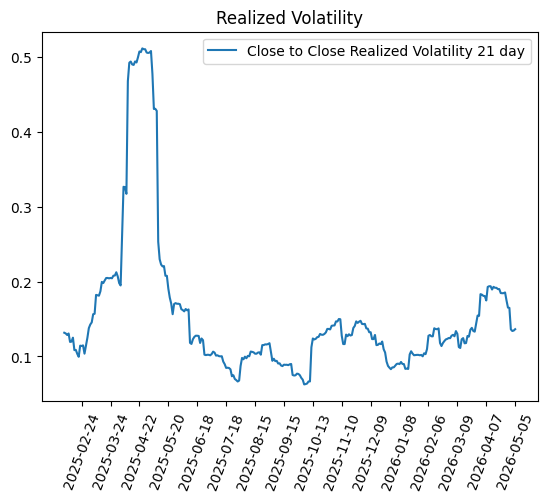

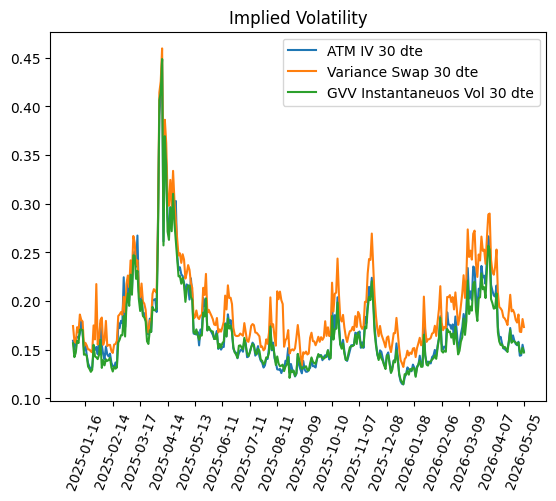

In [7]:
plt.plot(rvol_dates, rvol, label = "Close to Close Realized Volatility 21 day")
plt.xticks(rvol_dates[::-20], rotation=70)
plt.title("Realized Volatility")
plt.legend()
plt.show()

plt.plot(dates_ivs, ivs, label = "ATM IV 30 dte")
plt.plot(vs_dates, var_swaps, label = "Variance Swap 30 dte")
plt.plot(gvv_dates, gvv_iv, label = "GVV Instantaneuos Vol 30 dte")
plt.xticks(dates_ivs[::-20], rotation=70)
plt.title("Implied Volatility")
plt.legend()
plt.show()

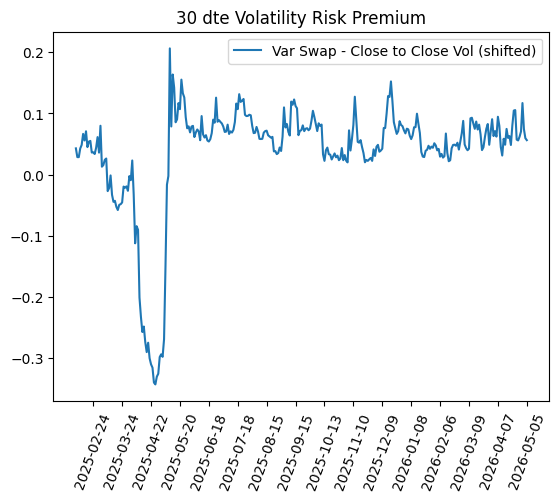

In [8]:
vrp = np.array(var_swaps[:-17]) - np.array(rvol)

plt.plot(rvol_dates, vrp, label="Var Swap - Close to Close Vol (shifted)")
plt.title("30 dte Volatility Risk Premium")
plt.xticks(rvol_dates[::-20], rotation=70)
plt.legend()
plt.show()

## Skew Risk Premium

#### Realized, Implied Data

In [9]:
# Realized Values
realized_sv_betas, realized_sv_covs, realized_sv_corrs, realized_sv_dates = an.rolling_spot_atm_iv_stats(ticker, start_date, end_date, 30)

# Implied Values
gvv_dates, gvv_spot_vol_corrs = rolling_gvv.spot_vol_corr(30)
gvv_10_moneyness_skew, gvv_10moneyness_dates = rolling_gvv.implied_skew_moneyness(dte = 30, weights = True)

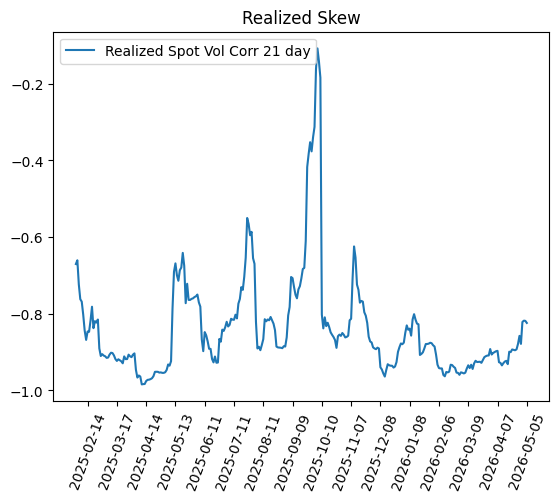

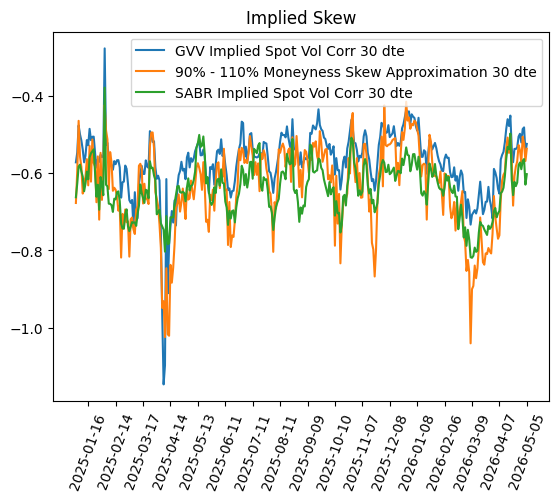

In [10]:
plt.plot(realized_sv_dates, realized_sv_corrs, label="Realized Spot Vol Corr 21 day")
plt.xticks(realized_sv_dates[::-20], rotation=70)
plt.title("Realized Skew")
plt.legend()
plt.show()

plt.plot(gvv_dates, gvv_spot_vol_corrs, label="GVV Implied Spot Vol Corr 30 dte")
plt.plot(gvv_10moneyness_dates, gvv_10_moneyness_skew, label="90% - 110% Moneyness Skew Approximation 30 dte")
plt.plot(sabr_dates, sabr_spot_vols, label="SABR Implied Spot Vol Corr 30 dte")
plt.xticks(gvv_dates[::-20], rotation = 70)
plt.title("Implied Skew")
plt.legend()
plt.show()

##### Neuberger skew

In [11]:
skew_swaps1 = []
skew_swaps2 = []
neuberger_skew_dates = []

for chain in chain_series:
    S = chain.S
    put_prices, call_prices, strikes, dtes = chain.get_equal_skew_prices(dte=30, max_days_diff=10) 

    skew_swap_strike = py_op.calc_engine.vol_engine.vol_funcs.skew_swap_fixed_leg_neuberger(S, put_prices, call_prices, strikes, dtes)

    var_strike = py_op.calc_engine.vol_engine.vol_funcs.variance_swap_fixed_leg_neuberger(S, put_prices, call_prices, strikes, dtes)
    entropy_cont = py_op.calc_engine.vol_engine.vol_funcs.entropy_contract_approximation(S, put_prices, call_prices, strikes, dtes)

    skew_swaps1.append(3*(entropy_cont - var_strike) / (var_strike) ** (3/2))
    skew_swaps2.append(skew_swap_strike)
    neuberger_skew_dates.append(chain.close_date)

In [12]:
realized_skews = an.rolling_analytics.realized_values.realized_skew_neuberger(30, chain_series)

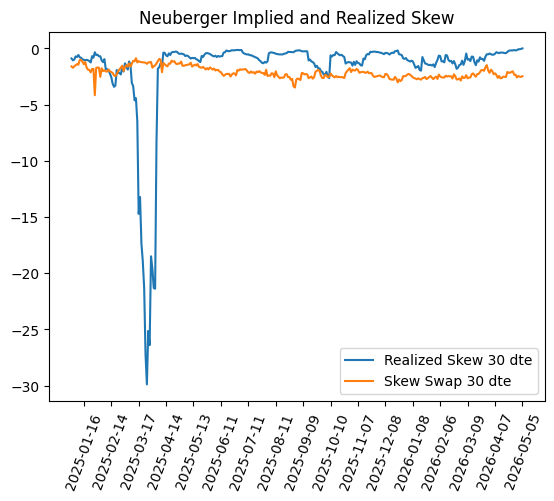

In [13]:
plt.plot(neuberger_skew_dates, realized_skews, label = "Realized Skew 30 dte")
plt.plot(neuberger_skew_dates, skew_swaps1, label = "Skew Swap 30 dte")
plt.title("Neuberger Implied and Realized Skew")
plt.xticks(neuberger_skew_dates[::-20], rotation=70)
plt.legend()
plt.show()

C:\Users\dibia\AppData\Local\Temp\ipykernel_8416\911133395.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


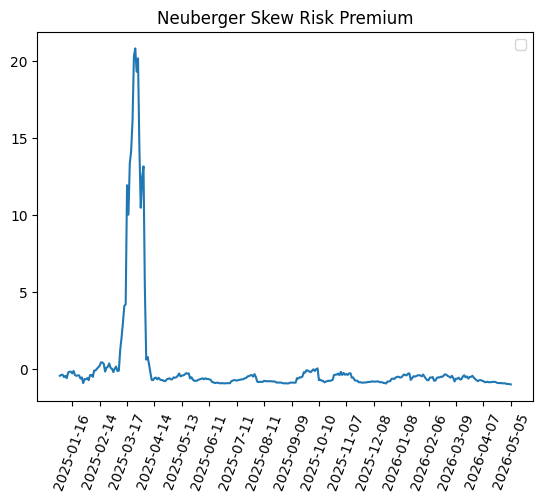

In [14]:
skew_risk_premium = (np.array(realized_skews) / np.array(skew_swaps1)) - 1

plt.plot(neuberger_skew_dates, skew_risk_premium)
plt.title("Neuberger Skew Risk Premium")
plt.xticks(neuberger_skew_dates[::-20], rotation=70)
plt.legend()
plt.show()
plt.show()

In [15]:
print(f"Avg xs: {np.mean(skew_risk_premium)}")
print(f"Avg rskew: {np.mean(realized_skews)}")
print(f"Avg skew: {np.mean(skew_swaps1)}")
print("-"*30)
print(f"Std xs: {np.std(skew_risk_premium)}")
print(f"Std rskew: {np.std(realized_skews)}")
print(f"Std skew: {np.std(skew_swaps1)}")

Avg xs: 0.11148922975924301
Avg rskew: -1.74547071821578
Avg skew: -2.128808645554232
------------------------------
Std xs: 3.1884071407489265
Std rskew: 4.1266240857049095
Std skew: 0.4998395850751323


## Vol of Vol Risk Premium

#### I am going to try the following realized vol of vol estimators
##### - Realized kurtosis
##### - Volatility of realized volatility (using rvol, log rvol, delta rvol, delta log rvol)
##### - Volatility of Vix
##### - Volatility of atm iv
##### - Formula from Hurst
#### For Implied vol of vol I can use
##### - GVV vol of vol
##### - Volatility of Vix
##### - VVIX

### Rolling Volatility Data

In [16]:
import pandas as pd
vix_1m_fut_data = pd.read_csv(r"C:\Users\dibia\OneDrive\Documents\Data\S&P 500 VIX 1M Futures 2020.01.01_2026.05.15.csv")
vix_1m_fut_data["Date"] = pd.to_datetime(vix_1m_fut_data["Date"])
vix_1m_fut_data = vix_1m_fut_data[
    (vix_1m_fut_data["Date"] >= start_date) &
    (vix_1m_fut_data["Date"] <= end_date)
]
vix_1m_fut_date, vix_1m_fut = vix_1m_fut_data["Date"].to_numpy(), vix_1m_fut_data["Price"].to_numpy()
# realized vol
rvol, rvol_dates = an.rolling_realized_volatility(ticker, start_date, end_date)

# implied vol related metrics
ivs, dates_ivs, spots = rolling_vol.constant_maturity_atm_iv(30)
var_swaps, vs_dates, spots = rolling_vol.constant_maturity_variance_swap_fixed_leg(30)
 
gvv_dates, gvv_vol_vol = rolling_gvv.vol_vol(30)

c:\Users\dibia\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_continuous_distns.py:5052: RuntimeWarning: Error in function boost::math::quantile(const inverse_gaussian_distribution<d>&, %1%): Unable to locate solution in a reasonable time: either there is no answer to quantile or the answer is infinite.  Current best guess is %1%
  ppf = np.asarray(scu._invgauss_ppf(x, mu, 1))


#### Realized vol of vol metrics

In [17]:
# realized kurtosis
realized_kurtosis = an.rolling_realized_kurtosis(ticker, start_date, end_date)

# close close rvol
drvol = np.diff(rvol)

drvol_vol = []
stvvs = [] # statistical vol-of-var

# rvol atm iv
div_rvol = np.diff(ivs)

driv_vol = []
mivvs = []
atm_iv_qv = []

# rvol var swap
dvar_swap_rvol = np.diff(var_swaps)

drvar_swap_vol = []
qv_var_swaps = []

# fed paper realized vol
vix_fut_log_ret = np.log(vix_1m_fut[1:] / vix_1m_fut[:-1])
vix_fut_rvol_vol = []

window_rv = 21
window_iv = 30
T = 30/365
dt = 1 / 252

for i in range(window_rv, len(rvol)):

    # realized vol of vol
    rolling_drvol = drvol[i - window_rv: i]
    # rolling_rvol = rvol[i - window_rv: i]
    # rolling_rvar = np.array(rolling_rvol)**2
    # mean_rolling_rvar = np.mean(rolling_rvar)
    # stvv = np.sum((rolling_rvar - mean_rolling_rvar) ** 2) / (window_rv - 1)

    drvol_vol.append(np.std(rolling_drvol, ddof=1) * np.sqrt(252))
    # stvvs.append(stvv)

for i in range(window_iv, len(ivs)):

    # realized vol of iv
    rolling_div_rvol = np.array(div_rvol[i - window_iv: i])
    rolling_ivs = ivs[i - window_iv: i + 1]
    div = np.diff(rolling_ivs)
    # qv = (T / (window_iv * dt)) * np.sum(div ** 2)
    qv = (1 / window_iv) * np.sum(div ** 2) * 252
    

    driv_vol.append(np.std(rolling_div_rvol, ddof=1) * np.sqrt(252))
    atm_iv_qv.append(np.sqrt(qv))

    # realized vol of var swaps
    rolling_drvar_swap_rvol = dvar_swap_rvol[i - window_iv: i]
    # qv_var_swap = (T / (window_iv * dt)) * np.sum(rolling_drvar_swap_rvol ** 2) * np.sqrt(252)
    qv_var_swap = np.sum(rolling_drvar_swap_rvol ** 2) * (252 / window_iv)

    drvar_swap_vol.append(np.std(rolling_drvar_swap_rvol, ddof=1) * np.sqrt(252))
    qv_var_swaps.append(np.sqrt(qv_var_swap))

    # fed paper rvol vol
    rolling_vix_fut_log_ret = vix_fut_log_ret[i - window_iv: i]
    rr_2 = 12*np.sum(rolling_vix_fut_log_ret**2)
    vix_fut_rvol_vol.append(rr_2)

# implied metrics
gvv_dates, gvv_vol_vol = rolling_gvv.vol_vol(30)
vvix_prices, vvix_dates = py_op.process_price_data.get_close_prices("^VVIX", start_date, end_date)

# clean up implied metrics

# convert to pandas Series indexed by dates
gvv_series = pd.Series(gvv_vol_vol, index=pd.to_datetime(gvv_dates))
vvix_series = pd.Series(vvix_prices, index=pd.to_datetime(vvix_dates))

# find dates that are in VVIX but not in GVV
missing_from_gvv = vvix_series.index.difference(gvv_series.index)

print("Dates in VVIX but missing from GVV:")
print(missing_from_gvv)

# keep only common dates
common_dates = gvv_series.index.intersection(vvix_series.index)

gvv_aligned = gvv_series.loc[common_dates]
vvix_aligned = vvix_series.loc[common_dates]

# clean up realized metrics

# Dates attached to each series
rvol_plot_dates = np.array(rvol_dates[window_rv:])
iv_plot_dates   = np.array(dates_ivs[window_iv:])
var_swap_plot_dates = np.array(vs_dates[window_iv:])

rvol_vals = np.array(drvol_vol)
iv_vals   = np.array(atm_iv_qv)
var_swap_vals = np.array(drvar_swap_vol)

# Convert both to datetime so matching is clean
rvol_plot_dates = pd.to_datetime(rvol_plot_dates)
iv_plot_dates   = pd.to_datetime(iv_plot_dates)
var_swap_plot_dates = pd.to_datetime(var_swap_plot_dates)

# Keep only rvol dates that are also in IV dates
mask = np.isin(rvol_plot_dates, iv_plot_dates)

rvol_dates_clean = rvol_plot_dates[mask]
rvol_vals_clean  = rvol_vals[mask]

Dates in VVIX but missing from GVV:
DatetimeIndex(['2025-08-06', '2025-09-26', '2025-10-01', '2025-10-02',
               '2025-12-26'],
              dtype='datetime64[ns]', freq=None)


#### Implied vol of vol metrics

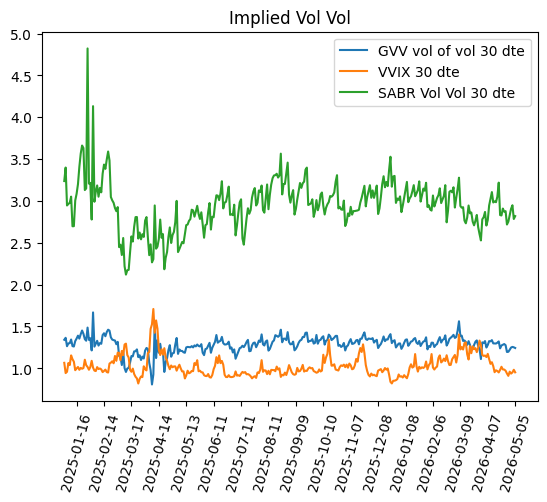

In [18]:
plt.plot(gvv_dates, gvv_aligned, label = "GVV vol of vol 30 dte")
plt.plot(gvv_dates, (vvix_aligned / 100), label = "VVIX 30 dte")
plt.plot(sabr_dates, np.array(sabr_vol_vols), label = "SABR Vol Vol 30 dte")
plt.xticks(gvv_dates[::-20], rotation = 75)
plt.title("Implied Vol Vol")
plt.legend()
plt.show()

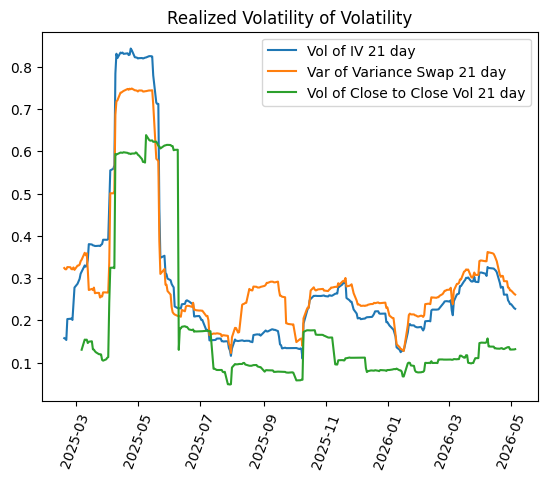

In [19]:
plt.plot(iv_plot_dates, iv_vals, label="Vol of IV 21 day")
plt.plot(var_swap_plot_dates, var_swap_vals, label = "Var of Variance Swap 21 day")
plt.plot(rvol_dates_clean, rvol_vals_clean, label="Vol of Close to Close Vol 21 day")

plt.xticks(rotation=70)
plt.legend()
plt.title("Realized Volatility of Volatility")
plt.show()

### Vol of Vol Descriptive Statistics

In [20]:
import numpy as np
import pandas as pd

series_dict = {
    "GVV Vol of Vol": gvv_aligned,
    "VVIX / 100": vvix_aligned / 100,
    "SABR Vol of Vol": sabr_vol_vols,
    "Vol of IV": iv_vals,
    "Vol of Variance Swap": var_swap_vals,
    "Close-to-Close Vol of Vol": rvol_vals_clean
}

# Convert to DataFrame, allowing unequal lengths by converting each to Series
df_stats_input = pd.DataFrame({
    name: pd.Series(np.asarray(values, dtype=float))
    for name, values in series_dict.items()
})

# Descriptive statistics
desc_stats = df_stats_input.describe().T

# Add extra useful stats
desc_stats["median"] = df_stats_input.median()
desc_stats["skew"] = df_stats_input.skew()
desc_stats["kurtosis"] = df_stats_input.kurtosis()

desc_stats

,count,mean,std,min,25%,50%,75%,max,median,skew,kurtosis
GVV Vol of Vol,330.0,1.289134,0.095500,0.807482,1.250348,1.299452,1.340536,1.668229,1.299452,-0.993116,4.040469
VVIX / 100,330.0,1.030138,0.124996,0.818900,0.952650,0.997500,1.083975,1.709200,0.997500,1.692742,4.445422
SABR Vol of Vol,330.0,2.947487,0.293490,2.119995,2.806090,2.953356,3.108572,4.822083,2.953356,0.655233,5.431181
Vol of IV,300.0,0.291562,0.189327,0.109316,0.178314,0.238248,0.300057,0.843279,0.238248,2.035942,3.121654
Vol of Variance Swap,300.0,0.303627,0.151893,0.122626,0.224972,0.270488,0.307496,0.748637,0.270488,2.071235,3.478262
Close-to-Close Vol of Vol,287.0,0.187418,0.177199,0.047889,0.087545,0.111301,0.173648,0.638348,0.111301,1.830318,1.639022
